# Flagging Vendor Invoices Manual For Manual Review 

## DATA ANALYSIS

In [98]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,MinMaxScaler 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report

In [5]:
import os

for root, dirs, files in os.walk(".."):
    if "inventory.db" in files:
        print(os.path.join(root, "inventory.db"))

../data/inventory.db


In [6]:
conn=sqlite3.connect("../data/inventory.db")

In [7]:
tables=pd.read_sql_query("SELECT name  FROM sqlite_master WHERE type='table'",conn)

In [8]:
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [10]:
for table in tables['name']:
    print('table name',table)
    df=pd.read_sql_query(f"SELECT * FROM {table} LIMIT 5 ",conn)
    display(df)

table name purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


table name purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


table name vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


table name begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


table name end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [13]:
purchase_agg_df=pd.read_sql_query("""
    SELECT 
        PONumber,
        COUNT(DISTINCT Brand) as total_brands,
        SUM(Quantity) as total_quantity,
        SUM(Dollars) as total_dollars,
        AVG(julianday(ReceivingDate)-julianday(PODate)) as avg_delay_recieving
    FROM purchases
    GROUP BY PONumber"""
    ,conn)

In [19]:
pd.read_sql_query("""

    SELECT
        PONumber,
        Quantity as invoice_quantity,
        Dollars as invoice_dollars,
        Freight,
        (julianday(InvoiceDate)-julianday(PODate)) as avg_pd_to_invoice,
        (julianday(PayDate)-julianday(PODate)) as avg_days_to_pay
    FROM vendor_invoice
""",conn)

,PONumber,invoice_quantity,invoice_dollars,Freight,avg_pd_to_invoice,avg_days_to_pay
0,8124,6,214.26,3.47,14.0,57.0
1,8137,15,140.55,8.57,16.0,61.0
2,8169,5,106.60,4.61,16.0,54.0
3,8106,10100,137483.78,2935.20,23.0,47.0
4,8170,1935,15527.25,429.20,14.0,50.0
...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,51.0
5539,13661,4617,37300.48,186.50,18.0,57.0
5540,13643,9848,202815.78,932.95,11.0,44.0
5541,13602,24747,149007.56,819.54,14.0,50.0


In [59]:
df=pd.read_sql_query("""

WITH purchase_agg_df as (
    SELECT 
        PONumber,
        COUNT(DISTINCT Brand) as total_brands,
        SUM(Quantity) as total_quantity,
        SUM(Dollars) as total_dollars,
        AVG(julianday(ReceivingDate)-julianday(PODate)) as avg_delay_recieving
    FROM purchases
    GROUP BY PONumber)

SELECT
    vi.PONumber,
    vi.Quantity as invoice_quantity,
    vi.Dollars as invoice_dollars,
    vi.Freight,
    (julianday(vi.InvoiceDate)-julianday(vi.PODate)) as pd_to_invoice,
    (julianday(vi.PayDate)-julianday(vi.InvoiceDate)) as days_to_pay,
    pa.total_brands,
    pa.total_quantity,
    pa.total_dollars,
    pa.avg_delay_recieving
    
FROM vendor_invoice vi LEFT JOIN purchase_agg_df pa ON vi.PONumber=pa.PONumber


""",conn)

In [60]:
df

,PONumber,invoice_quantity,invoice_dollars,Freight,pd_to_invoice,days_to_pay,total_brands,total_quantity,total_dollars,avg_delay_recieving
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809
...,...,...,...,...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0,2,223,6823.18,5.871795
5539,13661,4617,37300.48,186.50,18.0,39.0,110,24747,149007.56,5.050500
5540,13643,9848,202815.78,932.95,11.0,33.0,5,180,2559.72,5.000000
5541,13602,24747,149007.56,819.54,14.0,36.0,83,43240,318075.65,8.045541


In [61]:
df.isnull().sum()

PONumber               0
invoice_quantity       0
invoice_dollars        0
Freight                0
pd_to_invoice          0
days_to_pay            0
total_brands           0
total_quantity         0
total_dollars          0
avg_delay_recieving    0
dtype: int64

In [62]:
df.dtypes

PONumber                 int64
invoice_quantity         int64
invoice_dollars        float64
Freight                float64
pd_to_invoice          float64
days_to_pay            float64
total_brands             int64
total_quantity           int64
total_dollars          float64
avg_delay_recieving    float64
dtype: object

In [63]:
def create_invoice_risk_label(row):
    if (abs(row['invoice_dollars']-row['total_dollars'])>5):
        return 1
    if (row['avg_delay_recieving']>10):
        return 1
    else: return 0
df['flag_invoice']=df.apply(create_invoice_risk_label,axis=1)
df['flag_invoice'].value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

<Axes: xlabel='flag_invoice'>

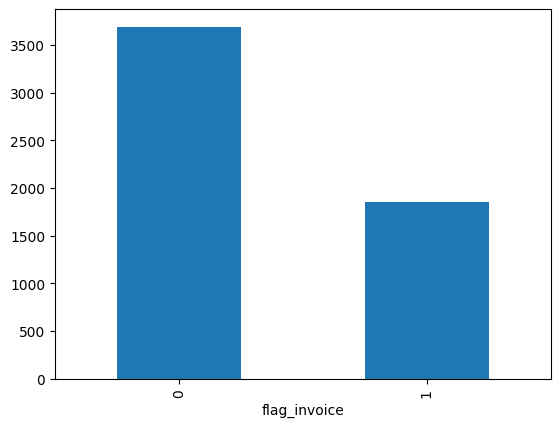

In [64]:
df['flag_invoice'].value_counts().plot(kind='bar')

<function matplotlib.pyplot.show(close=None, block=None)>

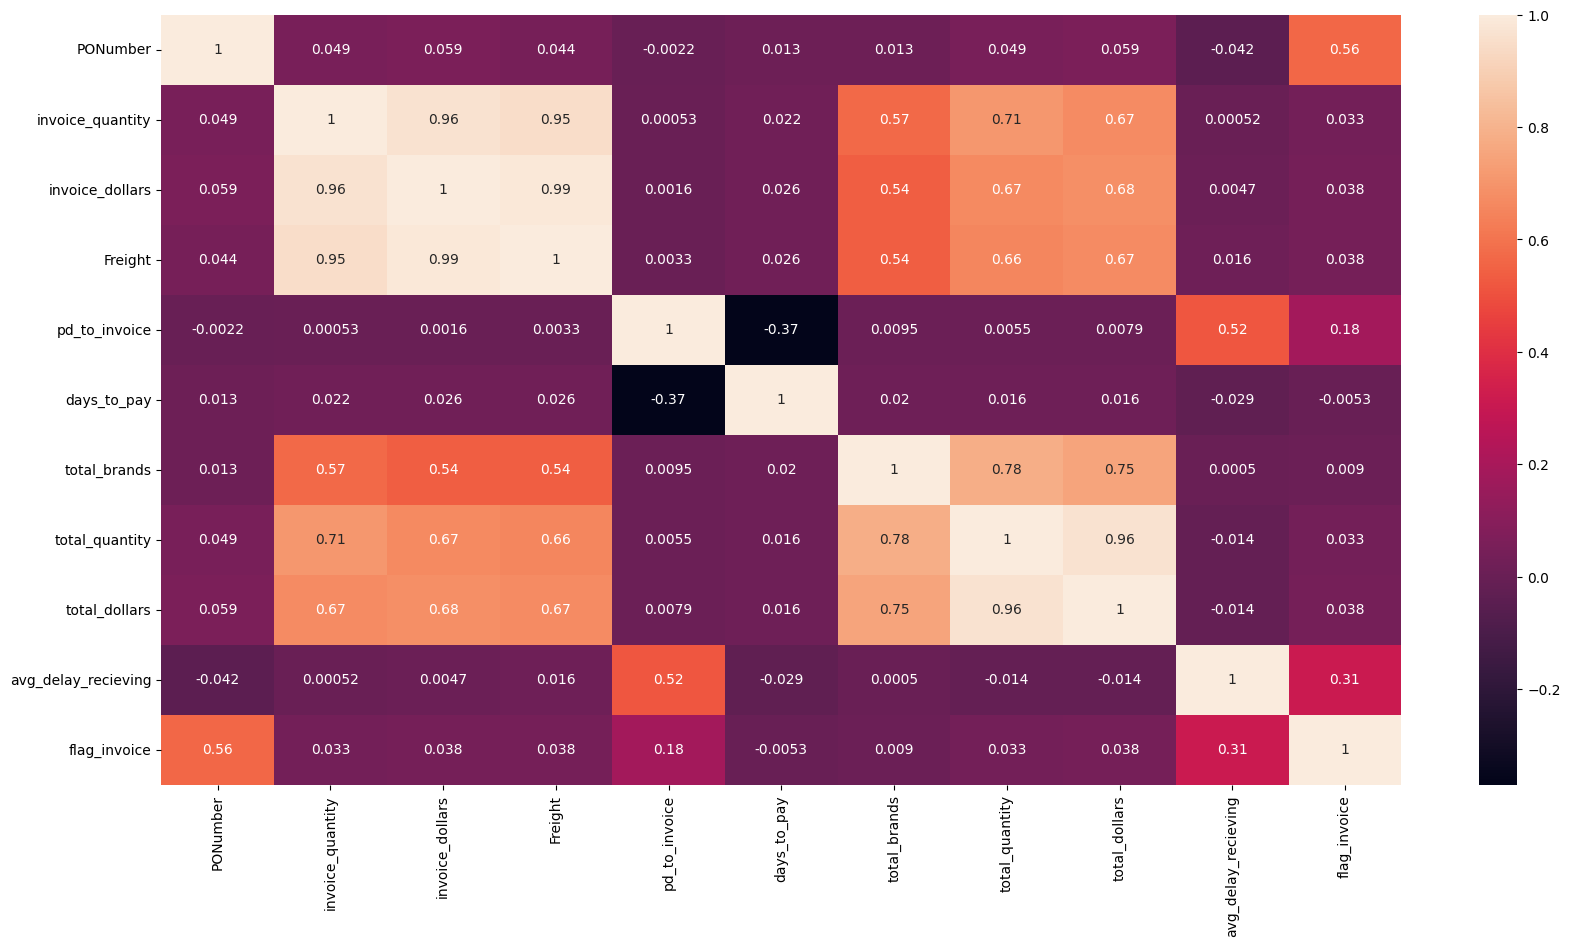

In [65]:
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(),annot=True)
plt.show

In [70]:
from scipy.stats import ttest_ind

flagged=df[df['flag_invoice']==1]
normal=df[df['flag_invoice']==0]

metrics=['invoice_quantity',    
'invoice_dollars',
'Freight',   
'pd_to_invoice',
'days_to_pay',
'total_brands',
'total_quantity',   
'total_dollars',       
'avg_delay_recieving',]

results=[]
significant_features=[]
non_significant_features=[]

for metric in metrics:
    flagged_mean=flagged[metric].mean()
    normal_mean=normal[metric].mean()

    t_stat,p_value=ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var=False
    )

    if p_value<0.05:
        significant_features.append(metric)
        results.append({
            "metric":metric,
            "flagged_mean": flagged_mean.round(2),
            "normal_mean": normal_mean.round(2),
            "p_value": p_value.round(3)
        })
    else:
        non_significant_features.append(metric)

In [71]:
non_significant_features

['days_to_pay', 'total_brands']

In [72]:
significant_features

['invoice_quantity',
 'invoice_dollars',
 'Freight',
 'pd_to_invoice',
 'total_quantity',
 'total_dollars',
 'avg_delay_recieving']

In [74]:
 pd.DataFrame(results)

,metric,flagged_mean,normal_mean,p_value
0,invoice_quantity,6728.28,5723.55,0.021
1,invoice_dollars,65600.61,54302.64,0.008
2,Freight,334.02,276.89,0.008
3,pd_to_invoice,17.23,16.02,0.000
4,total_quantity,6728.28,5723.55,0.021
5,total_dollars,65600.61,54302.64,0.008
6,avg_delay_recieving,8.47,7.27,0.000


## MACHINE LEARNING MODEL

In [115]:
def evaluate_model(model,X_test,y_test,model_name:str):
    pred=model.predict(X_test)

    accuracy=accuracy_score(y_test,pred)
    report=classification_report(y_test,pred)

    print(f'model_name: {model_name}')
    print(f'accuracy: {accuracy}')
    print(f'report:{report}')

In [116]:
X = df[['invoice_quantity','invoice_dollars','Freight','total_brands','total_quantity','pd_to_invoice','total_dollars']]
y = df['flag_invoice']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

model1=LogisticRegression(random_state=42)
model1.fit(X_train_scaled,y_train)

model2=DecisionTreeClassifier(random_state=42)
model2.fit(X_train_scaled,y_train)

model3=RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled,y_train)

evaluate_model(model1,X_test_scaled,y_test,'Logistic Regression')
evaluate_model(model2,X_test_scaled,y_test,'Decision Tree Classifier')
evaluate_model(model3,X_test_scaled,y_test,'Random Forest Classifier')

model_name: Logistic Regression
accuracy: 0.6582506762849414
report:              precision    recall  f1-score   support

           0       0.66      0.98      0.79       725
           1       0.56      0.06      0.11       384

    accuracy                           0.66      1109
   macro avg       0.61      0.52      0.45      1109
weighted avg       0.63      0.66      0.55      1109

model_name: Decision Tree Classifier
accuracy: 0.8115419296663661
report:              precision    recall  f1-score   support

           0       0.85      0.86      0.86       725
           1       0.74      0.71      0.72       384

    accuracy                           0.81      1109
   macro avg       0.79      0.79      0.79      1109
weighted avg       0.81      0.81      0.81      1109

model_name: Random Forest Classifier
accuracy: 0.8746618575293057
report:              precision    recall  f1-score   support

           0       0.85      0.98      0.91       725
           1       0.94

In [119]:
feature_importance=pd.DataFrame({
    "Feature":X_train.columns,
    "Feature Importance": model3.feature_importances_
}).sort_values(by="Feature Importance",ascending=False)

feature_importance

,Feature,Feature Importance
4,total_dollars,0.270810
3,total_quantity,0.200194
1,invoice_dollars,0.189611
2,Freight,0.177991
0,invoice_quantity,0.161393


## Hyperparameter Tuning

In [118]:
X = df[['invoice_quantity','invoice_dollars','Freight','total_quantity','total_dollars']]
y = df['flag_invoice']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

scaler=MinMaxScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

model3=RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled,y_train)

evaluate_model(model3,X_test_scaled,y_test,'Random Forest Classifier')

model_name: Random Forest Classifier
accuracy: 0.8872858431018936
report:              precision    recall  f1-score   support

           0       0.87      0.98      0.92       725
           1       0.94      0.72      0.82       384

    accuracy                           0.89      1109
   macro avg       0.90      0.85      0.87      1109
weighted avg       0.89      0.89      0.88      1109



In [122]:
param={
    "n_estimators":[100,200,300],
    "max_depth":[None,4,5,6],
    "min_samples_split":[3,4,5],
    "min_samples_leaf":[1,2,5],
    "criterion":['gini','entropy']
}

In [129]:
from sklearn.metrics import make_scorer,f1_score
from sklearn.model_selection import GridSearchCV

rf=RandomForestClassifier(random_state=42)

param={
    "n_estimators":[100,200,300],
    "max_depth":[None,4,5,6],
    "min_samples_split":[3,4,5],
    "min_samples_leaf":[1,2,5],
    "criterion":['gini','entropy']
}

scorer=make_scorer(f1_score)
grid_search=GridSearchCV(
    estimator=rf,
    param_grid=param,
    scoring=scorer,
    cv=5,
    verbose=2
)

grid_search.fit(X_train_scaled,y_train)
evaluate_model(grid_search,X_test_scaled,y_test,'Random Forest')

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=3, n_estimators=100; total time=   0.4s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=3, n_estimators=100; total time=   0.4s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=3, n_estimators=100; total time=   0.4s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=3, n_estimators=100; total time=   0.4s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=3, n_estimators=100; total time=   0.4s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=3, n_estimators=200; total time=   0.8s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=3, n_estimators=200; total time=   0.8s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=3, n_estimators=200; tot

In [130]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 300}

Flagged invoices have higher mean values then the Normal invoices, and the difference is statistically significant. This confirms that these features are primary driver of the review decision. This is a strong validation of the Business intuition.

Flagged invoices are associated with larger order size, higher financial exposure, greater operational complexity, and longer payment and receiving delays. They have significantly higher quantities, invoice values, freight costs, and number of brands, indicating that manual review is primarily driven by scale and complexity risk rather than isolated pricing anomalies. Additionally, longer payment and receiving delays suggest that flagged invoices are more likely to involve operational or reconciliation issues.
